# DPGExplainer Saga Benchmarks — Episode 2: Wine

A practitioner-friendly walkthrough of Decision Predicate Graphs (DPG) using the classic Wine dataset. We train a small Random Forest (RF), build a DPG to map the model’s global behavior using Explainable AI (XAI), and interpret three key properties to explain the model: Local Reaching Centrality (LRC), Betweenness Centrality (BC), and node communities.


## 1. What is Explainable AI (XAI)
Explainable AI (XAI) focuses on making model behavior understandable to people. It helps answer questions like why a prediction was made, what features mattered most, and whether the model behaves as intended.

Common motivations for XAI include:
- Explain to justify: Provide evidence for decisions in high-stakes contexts.
- Explain to discover: Surface patterns, biases, or unexpected signals in the data.
- Explain to improve: Debug models, features, and data issues.
- Explain to control: Support monitoring, governance, and compliance.

XAI methods are often grouped into:
- Global explanations: Summarize how the model behaves overall.
- Local explanations: Explain a single prediction or a small region of the feature space.

SHAP is a popular local method, while DPG provides a global view by turning an ensemble into a predicate graph and analyzing its structure.


## 2. Why DPG (in one minute)
Tree ensembles, such as RF, can be accurate but hard to interpret globally. DPG converts the ensemble into a graph where:
- Nodes are predicates like `alcohol <= 13.5`, in the wine case.
- Edges capture how often training samples traverse those predicates
- Metrics quantify how predicates structure the model’s global reasoning

This gives a global map of decision logic and allows the use of graph metrics to capture the model’s rationale.

In the next steps, we create a Random Forest model of the Iris dataset and explain it with DPG.


## 3. Setup (Wine + Random Forest + DPG)

We first train a baseline Random Forest, then inspect pairwise feature/class structure with a pair plot.


In [30]:
%pip install --force-reinstall --no-deps git+https://github.com/Meta-Group/DPG.git


  Cloning https://github.com/Meta-Group/DPG.git to /private/var/folders/gc/mhnpykzn5n15__6zh66dkf6r0000gn/T/pip-req-build-o0xwvunj
  Running command git clone --filter=blob:none --quiet https://github.com/Meta-Group/DPG.git /private/var/folders/gc/mhnpykzn5n15__6zh66dkf6r0000gn/T/pip-req-build-o0xwvunj
  Resolved https://github.com/Meta-Group/DPG.git to commit d7a4e6f2f2f8646d6326f89a8c5fc525d93f6a57
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dpg: filename=dpg-0.1.5-py3-none-any.whl size=39591 sha256=aefaf6d6651a70a5595ee75e4148059679c78ebdea57e05d90b9ed8acd405990
  Stored in directory: /private/var/folders/gc/mhnpykzn5n15__6zh66dkf6r0000gn/T/pip-ephem-wheel-cache-l239f32c/wheels/dc/1b/f7/79000c8935cb0c07cc77c2dd6e4931f0bc0ff84c354271fdbc
Successfully built dpg
  Attempting uninstall: dpg
    Found existing installation: dpg 0.1.5
    Uninstalling dpg-0.1.5:
      Successfull

In [31]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



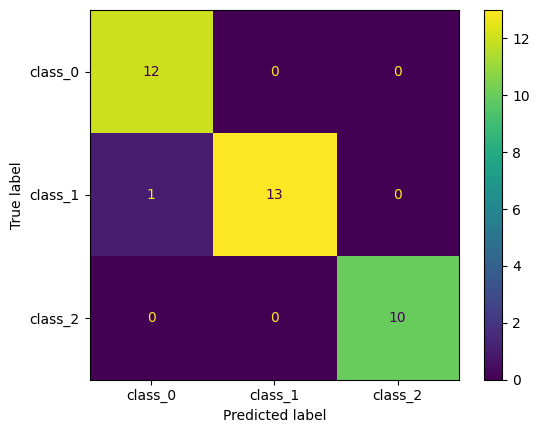

In [32]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from dpg import DPGExplainer

IMG_DIR = Path('images')
IMG_DIR.mkdir(parents=True, exist_ok=True)

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=10, random_state=27)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=wine.target_names)
disp.plot()
disp.figure_.savefig(IMG_DIR / 'rf_confusion_matrix.png', dpi=200, bbox_inches='tight')
print(classification_report(y_test, y_pred, target_names=wine.target_names))


### 3.1 Pair Plot (All Features by Class)


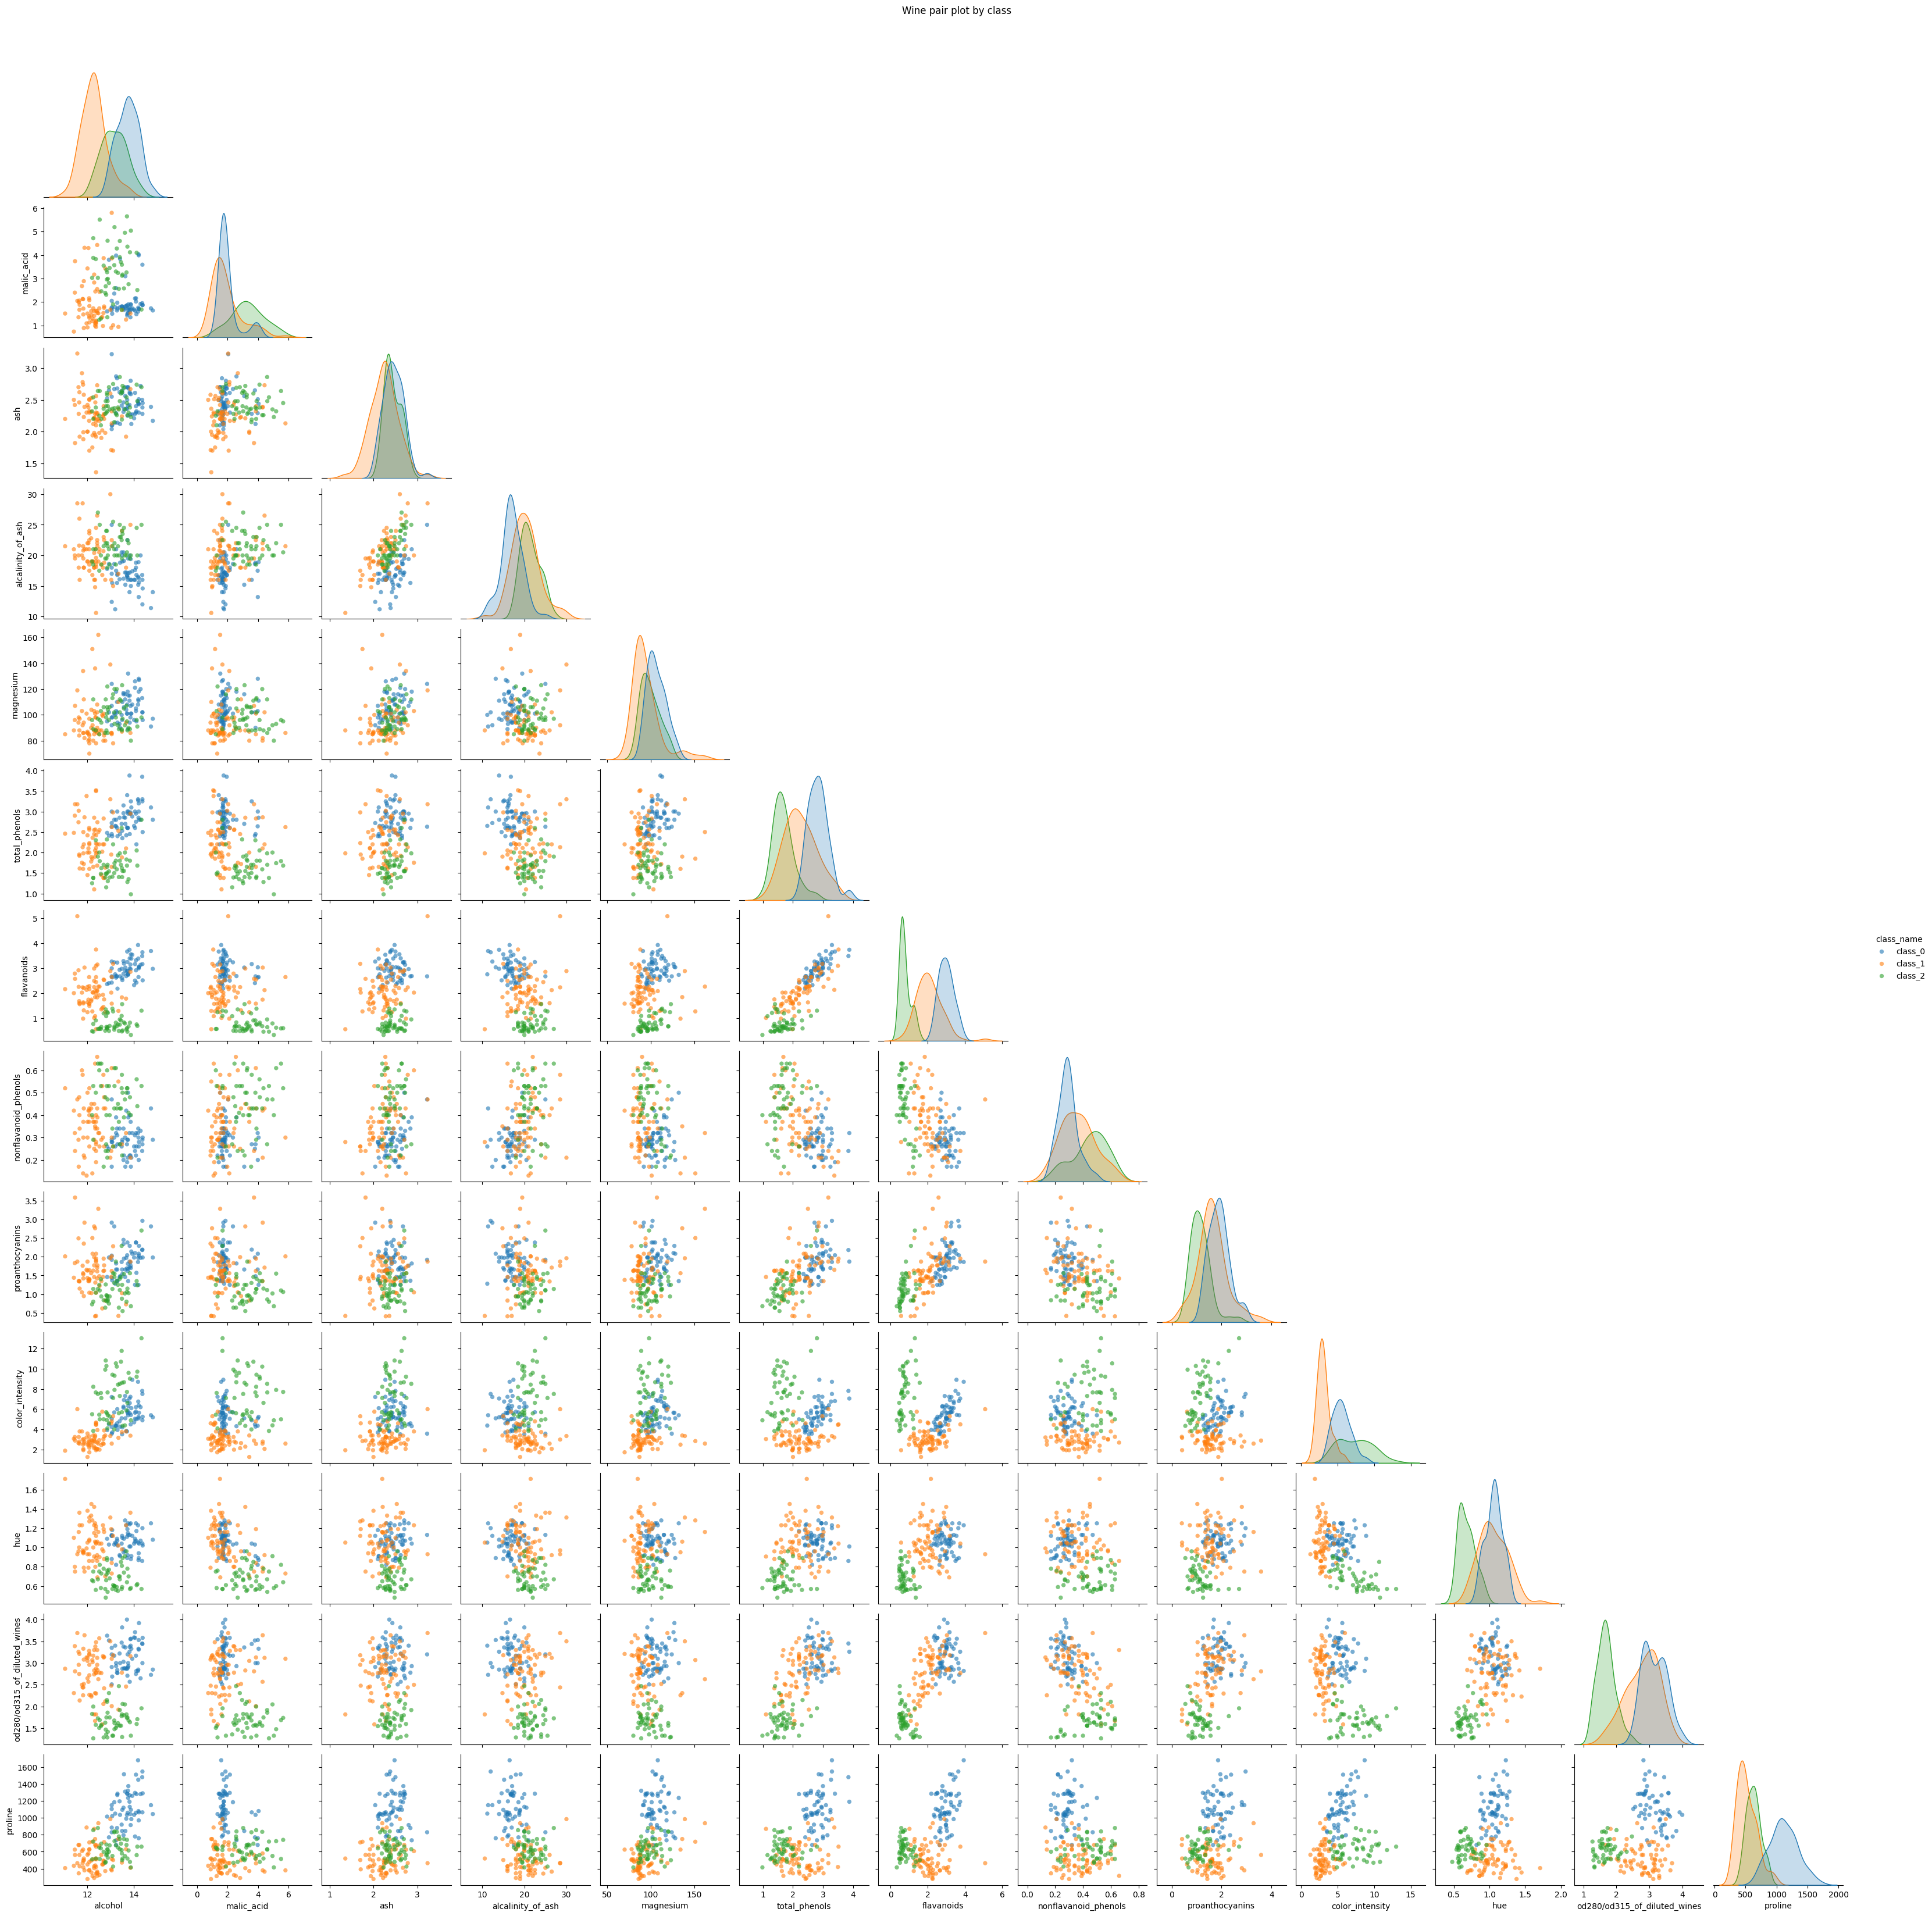

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_df = X.copy()
pair_df['class_name'] = y.map(lambda i: wine.target_names[i])

g = sns.pairplot(
    pair_df,
    hue='class_name',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 28, 'edgecolor': 'none'},
)
g.fig.suptitle('Wine pair plot by class', y=1.02)
g.fig.savefig(IMG_DIR / 'pairplot.png', dpi=200, bbox_inches='tight')
plt.show()


## 4. Extracting DPG from RF

Next, we extract the DPG from our RF model. The parameters `feature_names` and `target_names` provide readable output for the mapped scenarios.


In [34]:
explainer = DPGExplainer(
    model=model,
    feature_names=X.columns,
    target_names=wine.target_names.tolist(),
    config_file="config.yaml",  # optional if present
)

explanation = explainer.explain_global(
    X.values,
    communities=True,
    community_threshold=0.2,
)


Config file not found at 'config.yaml'. Using built-in defaults.
DPG initialized with perc_var=1e-09, decimal_threshold=6, n_jobs=-1

Starting DPG extraction *****************************************
Model Class: RandomForestClassifier
Model Class Module: sklearn.ensemble._forest
Model Estimators:  10
Model Params:  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': 27, 'verbose': 0, 'warm_start': False}
*****************************************************************


100%|██████████| 178/178 [00:00<00:00, 509.13it/s]


Total of paths: 1780
Building DPG...


Processing cases: 100%|██████████| 1780/1780 [00:00<00:00, 19853.27it/s]


Extracting graph...


/Users/barbon/Python/DPG/.venv/lib/python3.11/site-packages/metrics/graph.py:337: RuntimeWarning: divide by zero encountered in matmul
  B = N @ R
/Users/barbon/Python/DPG/.venv/lib/python3.11/site-packages/metrics/graph.py:337: RuntimeWarning: overflow encountered in matmul
  B = N @ R
/Users/barbon/Python/DPG/.venv/lib/python3.11/site-packages/metrics/graph.py:337: RuntimeWarning: invalid value encountered in matmul
  B = N @ R


## 5. Read the DPG Metrics


In [35]:
explanation.node_metrics.head()


,Node,Degree,In degree nodes,Out degree nodes,Betweenness centrality,Local reaching centrality,Label
0,304910727942443171335447234861625442905234948809,3,1,2,0.000598,0.002564,proanthocyanins > 2.475
1,801067633408911886824554548111805927237221319134,2,1,1,0.000066,0.000256,malic_acid > 1.94
2,1274122882655954440831925413946465656943344548989,23,23,0,0.000000,0.000000,Class class_0
3,1457201784724408801215259549719773174331561325554,3,1,2,0.000299,0.004616,malic_acid <= 1.68
4,565082277432391296809382963823190663333181519091,2,1,1,0.000133,0.000256,color_intensity > 4.2


**Local Reaching Centrality (LRC)**
- High LRC nodes can reach many other nodes downstream.
- These predicates often act early, framing large portions of the model’s logic.

**Betweenness Centrality (BC)**
- High BC nodes lie on many shortest paths between other nodes.
- These predicates are “bottlenecks” that connect major decision flows.


## 6. Compare Top LRC Predicates vs Random Forest Importance


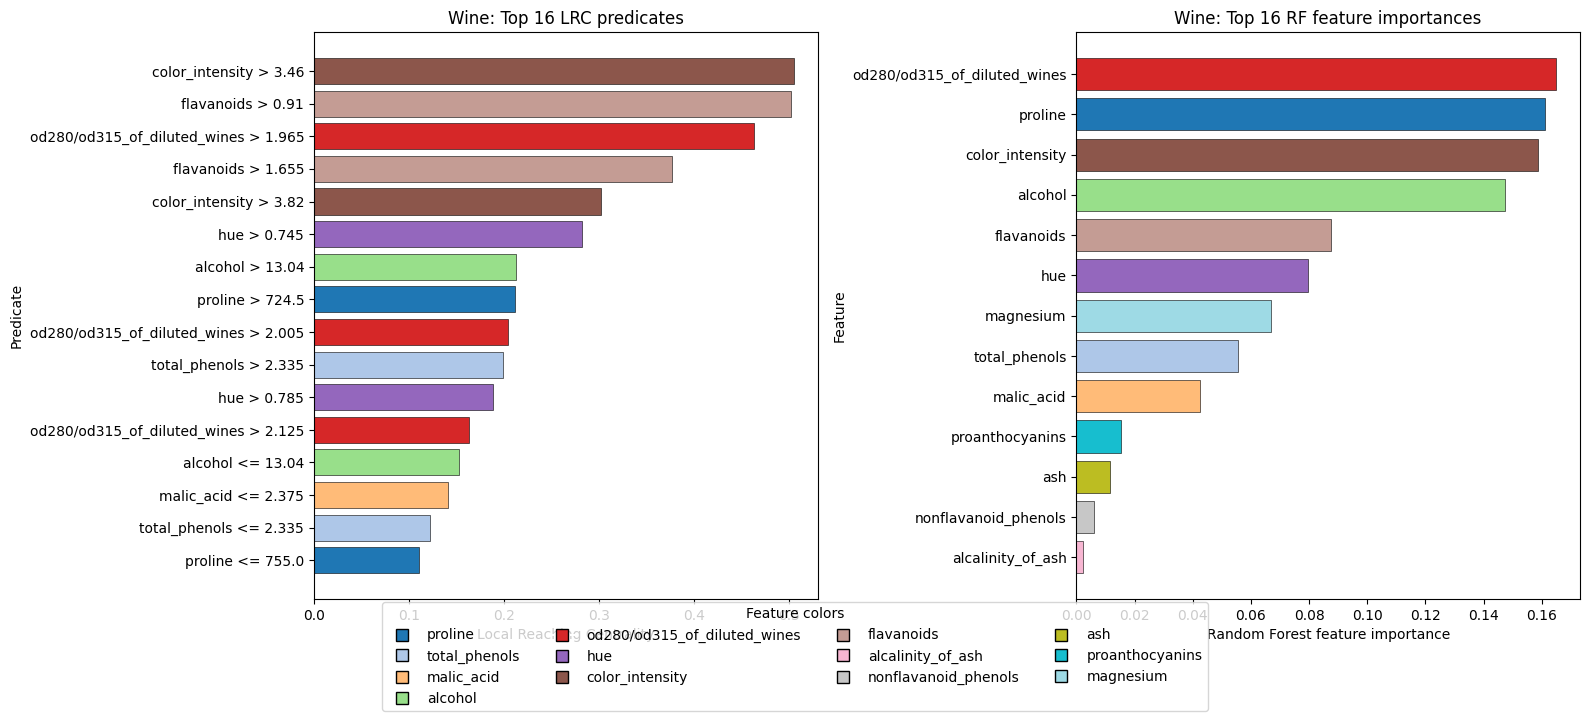

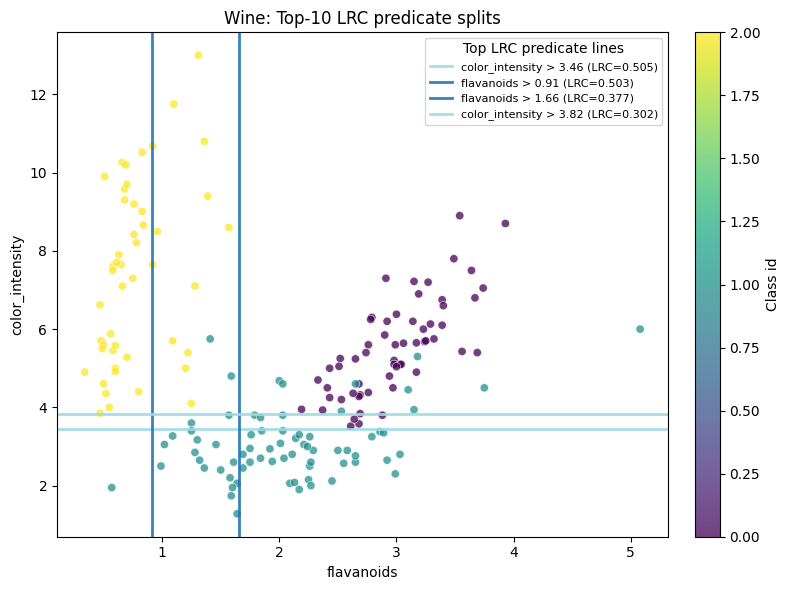

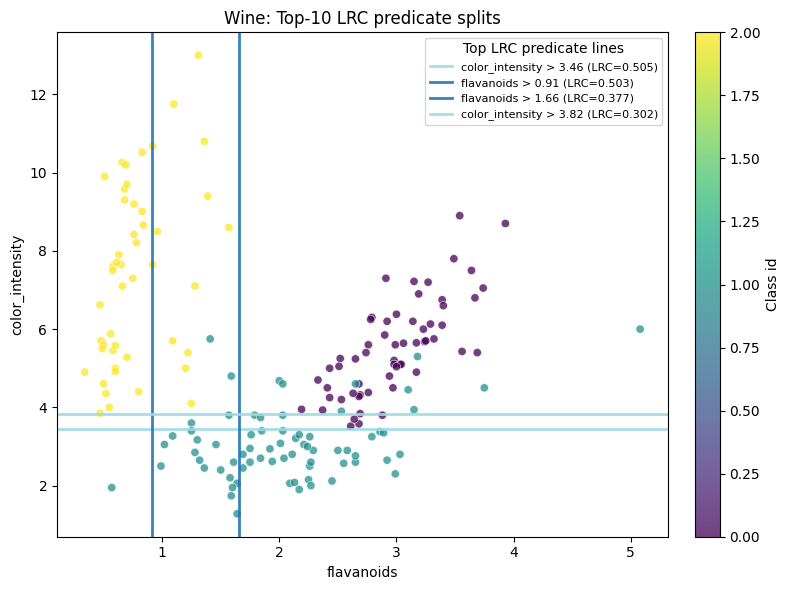

In [36]:
from dpg.visualizer import plot_lrc_vs_rf_importance, plot_top_lrc_predicate_splits

plot_lrc_vs_rf_importance(
    explanation=explanation,
    model=model,
    X_df=X,
    top_k=16,
    dataset_name='Wine',
    save_path=str(IMG_DIR / 'lrc_vs_rf_importance.png'),
    show=True,
)

plot_top_lrc_predicate_splits(
    explanation=explanation,
    X_df=X,
    y=y,
    top_predicates=10,
    top_features=2,
    dataset_name='Wine',
    save_path=str(IMG_DIR / 'top_lrc_predicate_splits.png'),
    show=True,
)


### Optional: inspect top-10 LRC and RF tables


In [37]:
top_lrc = (
    explanation.node_metrics
    .loc[
        explanation.node_metrics['Label'].astype(str).str.contains('<=', regex=False)
        | explanation.node_metrics['Label'].astype(str).str.contains('>', regex=False),
        ['Label', 'Local reaching centrality'],
    ]
    .sort_values('Local reaching centrality', ascending=False)
    .head(10)
)

top_rf = (
    pd.DataFrame({
        'feature': list(getattr(model, 'feature_names_in_', X.columns)),
        'rf_importance': model.feature_importances_.astype(float),
    })
    .sort_values('rf_importance', ascending=False)
    .head(10)
)

display(top_lrc)
display(top_rf)


,Label,Local reaching centrality
156,color_intensity > 3.46,0.504830
174,flavanoids > 0.91,0.502640
170,od280/od315_of_diluted_wines > 1.965,0.463310
124,flavanoids > 1.655,0.377340
133,color_intensity > 3.82,0.302024
171,hue > 0.745,0.281635
116,alcohol > 13.04,0.212821
54,proline > 724.5,0.211581
161,od280/od315_of_diluted_wines > 2.005,0.204453
139,total_phenols > 2.335,0.199512


,feature,rf_importance
11,od280/od315_of_diluted_wines,0.164883
12,proline,0.161166
9,color_intensity,0.158853
0,alcohol,0.147452
6,flavanoids,0.087611
10,hue,0.079530
4,magnesium,0.067015
5,total_phenols,0.055643
1,malic_acid,0.042399
8,proanthocyanins,0.015424


Interpretation guide:
- If a predicate has **high LRC**, it likely sets an early rule that shapes many later decisions.
- If a feature has **high RF importance**, it contributes strongly to split quality across the forest.
- Compare overlap: when high-LRC predicates and high-RF features agree, the global graph and model-level importance tell a consistent story.

### BC analysis
This notebook includes a BC bottleneck cloud in PCA space (Section 7).
A full BC ranking-focused analysis will be covered in a separate session/notebook.


## 7. Show BC Bottleneck Cloud in PCA Space


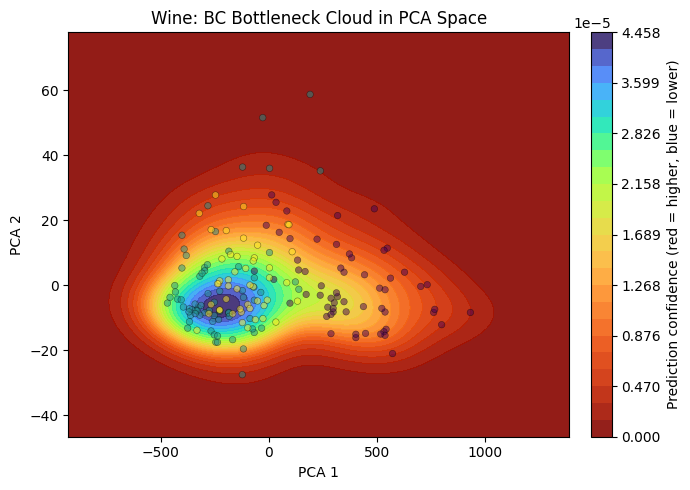

In [38]:
import seaborn as sns
from sklearn.decomposition import PCA
import re

def bc_weights_from_explanation(explanation, X_df, top_k=10):
    nm = explanation.node_metrics.copy()
    nm = nm[nm["Label"].str.contains("<=", regex=False, na=False) | nm["Label"].str.contains(">", regex=False, na=False)].copy()
    top_bc = nm.sort_values("Betweenness centrality", ascending=False).head(top_k)

    weights = np.zeros(len(X_df), dtype=float)

    for _, row in top_bc.iterrows():
        parsed = re.search(r"(.+?)\s*(<=|>)\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", str(row["Label"]))
        if not parsed:
            continue
        feature = parsed.group(1).strip()
        op = parsed.group(2)
        threshold = float(parsed.group(3))
        if feature not in X_df.columns:
            continue

        vals = X_df[feature].values
        vals = np.where(np.isfinite(vals), vals, np.nan)
        if op == '<=':
            weights += (vals <= threshold)
        else:
            weights += (vals > threshold)

    if weights.max() > 0:
        weights = weights / weights.max()
    return weights


def pca_kde_plot(X_df, y, weights, title, save_path=None):
    X_clean = X_df.replace([np.inf, -np.inf], np.nan)
    valid_mask = ~X_clean.isna().any(axis=1)
    X_valid = X_clean[valid_mask]
    y_valid = y[valid_mask]
    w_valid = weights[valid_mask]

    pca = PCA(n_components=2, random_state=27)
    X_pca = pca.fit_transform(X_valid)

    fig, ax = plt.subplots(1, 1, figsize=(7, 5), facecolor='white')
    ax.set_facecolor('#f6d6d6')

    try:
        kde = sns.kdeplot(
            x=X_pca[:, 0],
            y=X_pca[:, 1],
            weights=w_valid,
            fill=True,
            levels=25,
            cmap='turbo_r',
            alpha=0.9,
            thresh=0.0,
            bw_adjust=1.15,
            ax=ax,
        )
        if hasattr(kde, 'collections') and kde.collections:
            cbar = fig.colorbar(kde.collections[0], ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('Prediction confidence (red = higher, blue = lower)')
    except Exception:
        hb = ax.hexbin(
            X_pca[:, 0],
            X_pca[:, 1],
            C=w_valid,
            reduce_C_function=np.mean,
            gridsize=35,
            cmap='turbo_r',
            mincnt=1,
            alpha=0.9,
        )
        cbar = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Prediction confidence (red = higher, blue = lower)')

    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y_valid,
        cmap='viridis',
        s=22,
        alpha=0.5,
        edgecolor='k',
        linewidth=0.4,
    )

    ax.set_title(title)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


weights = bc_weights_from_explanation(explanation, X, top_k=10)
pca_kde_plot(
    X, y, weights, 'Wine: BC Bottleneck Cloud in PCA Space',
    save_path=IMG_DIR / 'bc_bottleneck_pca_cloud.png'
)



## 8. Communities (Decision Themes + Class Complexity)

Beyond visualization, we quantify class complexity with class-vs-feature predicate counts:
- Heatmap (absolute counts): how many predicates involving each feature can reach each class node
- Heatmap (row-normalized): per-class feature distribution
- Bar plots: predicate volume and unique feature coverage per class


In [39]:
# Communities overview + complexity-oriented class-feature analysis
import seaborn as sns
from dpg.visualizer import class_feature_predicate_counts

def plot_class_feature_complexity(heat_df, dataset_name='Wine', top_n_features=15, save_prefix=None):
    if heat_df.empty:
        print(f'{dataset_name}: no class-feature predicate counts available.')
        return

    h = heat_df.copy()
    if h.shape[1] > top_n_features:
        h = h.iloc[:, :top_n_features]

    h_norm = h.div(h.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.6 * len(h.index) + 2)))

    sns.heatmap(
        h,
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        linewidths=0.4,
        linecolor='white',
        ax=axes[0],
    )
    axes[0].set_title(f'{dataset_name}: Class vs Feature predicate counts')
    axes[0].set_xlabel('Feature')
    axes[0].set_ylabel('Class')

    sns.heatmap(
        h_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.4,
        linecolor='white',
        ax=axes[1],
    )
    axes[1].set_title(f'{dataset_name}: Row-normalized feature share by class')
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('Class')

    plt.tight_layout()
    if save_prefix is not None:
        fig.savefig(save_prefix + '_heatmap.png', dpi=200, bbox_inches='tight')
    plt.show()

    complexity = pd.DataFrame({
        'total_predicates': h.sum(axis=1),
        'unique_features': (h > 0).sum(axis=1),
    }).sort_values('total_predicates', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(
        x=complexity.index,
        y=complexity['total_predicates'],
        palette='Reds_r',
        ax=axes[0],
    )
    axes[0].set_title(f'{dataset_name}: Predicate volume by class')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Total predicate count')

    sns.barplot(
        x=complexity.index,
        y=complexity['unique_features'],
        palette='Blues_r',
        ax=axes[1],
    )
    axes[1].set_title(f'{dataset_name}: Feature coverage by class')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Unique features in predicates')

    plt.tight_layout()
    if save_prefix is not None:
        fig.savefig(save_prefix + '_bars.png', dpi=200, bbox_inches='tight')
    plt.show()


In [40]:
explanation.communities.keys()
explanation.communities.get("Clusters", explanation.communities.get("Communities", []))


{'Class class_0': ['malic_acid > 1.94',
  'Class class_0',
  'color_intensity > 4.2',
  'malic_acid <= 2.22',
  'malic_acid > 2.765',
  'total_phenols <= 2.635',
  'od280/od315_of_diluted_wines > 2.465',
  'magnesium > 94.5',
  'proanthocyanins > 1.545',
  'alcohol > 12.59',
  'proline > 755.0',
  'nonflavanoid_phenols <= 0.225',
  'od280/od315_of_diluted_wines > 2.285',
  'total_phenols <= 2.775',
  'od280/od315_of_diluted_wines > 3.73',
  'hue > 0.725',
  'malic_acid <= 4.89',
  'proline > 724.5',
  'alcohol > 13.205',
  'od280/od315_of_diluted_wines > 2.25',
  'total_phenols > 2.075',
  'od280/od315_of_diluted_wines > 2.26',
  'alcohol > 12.785',
  'proline > 679.0',
  'proline > 652.5',
  'od280/od315_of_diluted_wines > 2.82',
  'od280/od315_of_diluted_wines > 2.46',
  'ash > 2.235',
  'proline > 707.5',
  'hue > 0.805',
  'alcohol > 13.04',
  'total_phenols > 2.275',
  'flavanoids > 1.655',
  'alcalinity_of_ash <= 22.75',
  'total_phenols > 2.04',
  'color_intensity > 3.82',
  'ma

Plotting DPG...


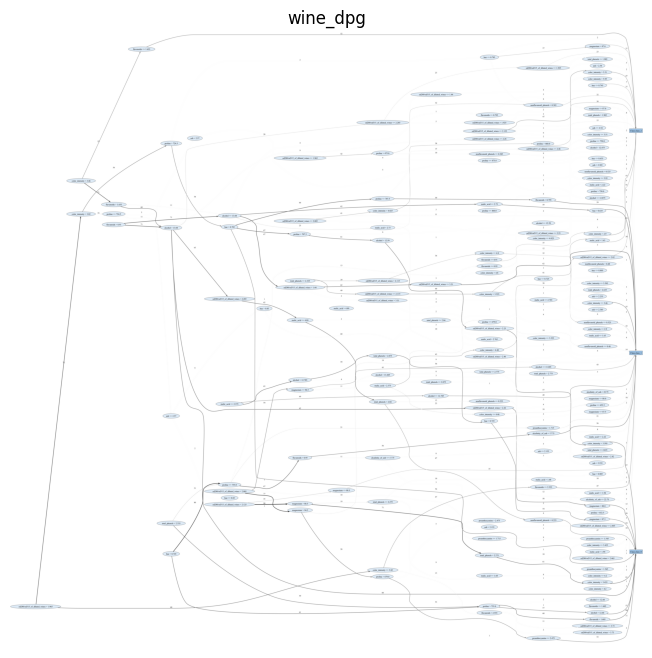

In [41]:
run_name = "wine_dpg"
explainer.plot(run_name, explanation, save_dir=str(IMG_DIR), class_flag=True, export_pdf=True, dpi=600)


Plotting DPG (communities)...


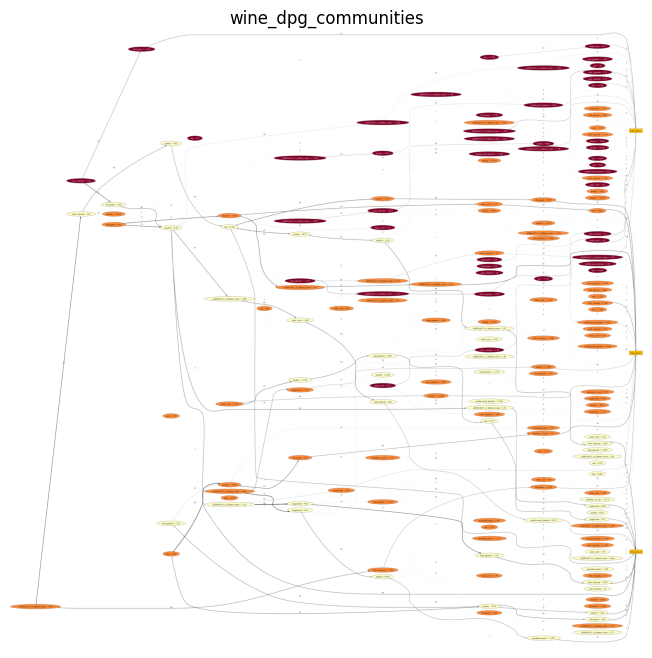

In [42]:
run_name = "wine_dpg"
explainer.plot_communities(run_name, explanation, save_dir=str(IMG_DIR), class_flag=True, export_pdf=True, dpi=600)


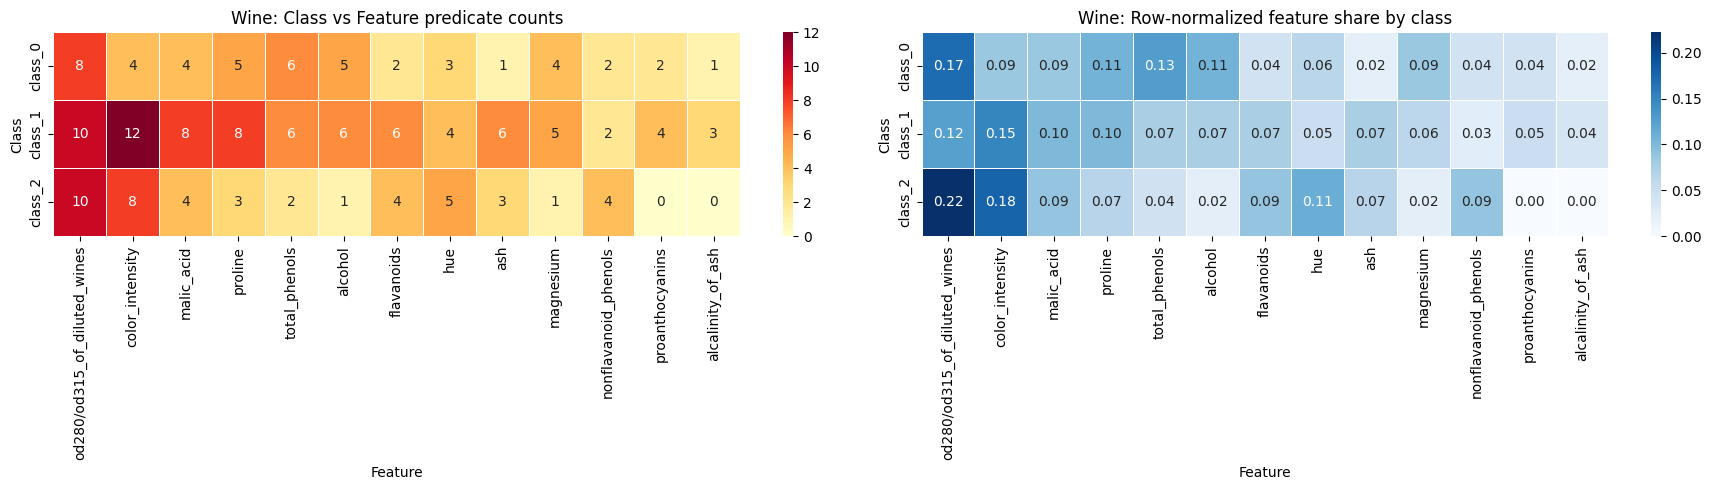

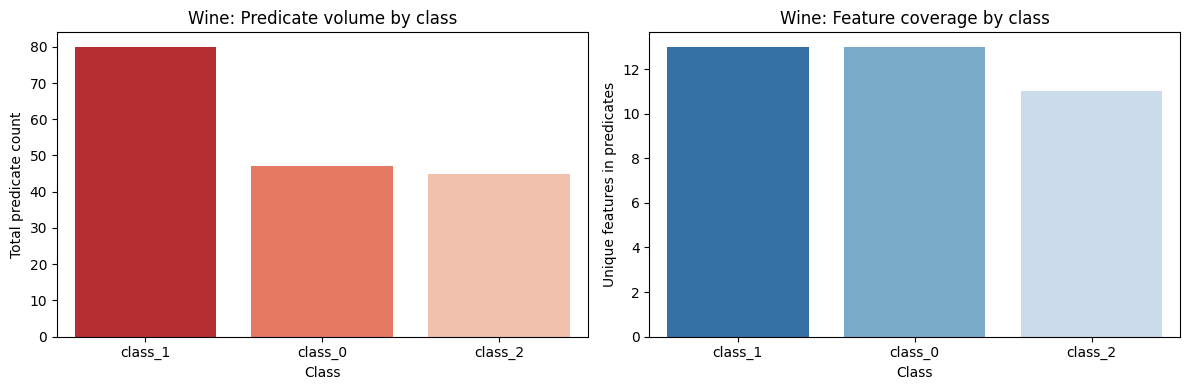

In [43]:
heat = class_feature_predicate_counts(explanation)
plot_class_feature_complexity(
    heat, dataset_name='Wine', top_n_features=15,
    save_prefix=str(IMG_DIR / 'communities_class_feature_complexity')
)


In [44]:
from dpg.visualizer import (
    classwise_feature_bounds_from_communities,
    class_feature_predicate_positions,
    class_lookup_from_target_names,
    plot_dpg_class_bounds_vs_dataset_feature_ranges,
)


In [45]:
class_bounds = classwise_feature_bounds_from_communities(explanation)
print(class_bounds)
class_lookup = class_lookup_from_target_names(wine.target_names if 'wine' in globals() else None)
predicate_positions = class_feature_predicate_positions(explanation)
print(predicate_positions.head(10))


   class_name  community_id                       feature  lower_bound  \
0     class_0             0                       proline      652.500   
1     class_0             0                    flavanoids        1.605   
2     class_0             0                    malic_acid        1.940   
3     class_0             0                 total_phenols        2.040   
4     class_0             0                       alcohol       12.590   
5     class_0             0                           hue        0.725   
6     class_0             0                           ash        2.235   
7     class_0             0               color_intensity        3.435   
8     class_0             0  od280/od315_of_diluted_wines        2.125   
9     class_0             0               proanthocyanins        1.545   
10    class_0             0          nonflavanoid_phenols        0.225   
11    class_0             0                     magnesium       87.500   
12    class_0             0           

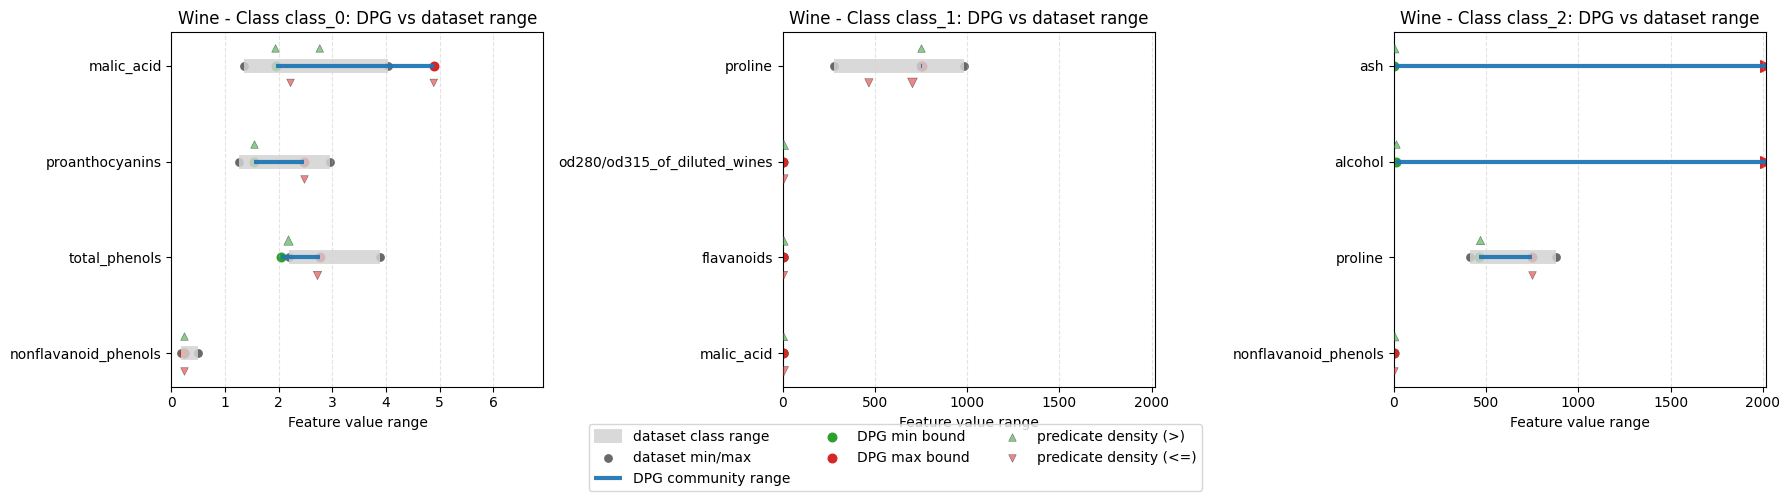

In [46]:
_ = plot_dpg_class_bounds_vs_dataset_feature_ranges(
    explanation=explanation,
    X_df=X,
    y=y,
    dataset_name='Wine',
    top_features=4,
    class_lookup=class_lookup,
    predicate_positions=predicate_positions,
    class_bounds=class_bounds,
    save_path=str(IMG_DIR / 'dpg_vs_dataset_feature_ranges.png'),
)


## 9. What to Say in the Story
Use this narrative to highlight **all DPG contributions** in a practitioner discussion:

- **LRC as a global logic driver (alternative lens to RF importance):** LRC identifies predicates that sit high in the decision flow and influence many downstream rules. While RF feature importance ranks features by split contribution, LRC shows *which concrete thresholds/rules* organize the model reasoning graph.
- **BC as bottleneck decision logic:** Betweenness centrality pinpoints predicates that connect major decision paths. In the PCA/BC cloud view, these predicates appear where dense transitional regions emerge, helping explain where the model switches between class regimes.
- **Communities for class-boundary structure:** Community groups reveal predicate themes per class and show how boundaries are formed as connected rule sets, not isolated splits. This makes class definitions interpretable at graph level.
- **Overlapped classes diagnosis:** Shared/neighboring communities and ambiguous regions expose where classes overlap (e.g., Versicolor vs Virginica), indicating where predictions are naturally harder and where boundary rules are less separable.
- **Class simplicity/complexity profiling:** Community-level predicate concentration and class complexity scores indicate which classes are explained by compact, stable rule sets (simpler) versus distributed, multi-threshold rule systems (more complex).
- **Class definition vs original dataset statistics:** Compare DPG predicates/boundaries with class-wise feature statistics (means, spreads, quantiles) from the raw data to validate whether discovered rules align with empirical class distributions and to detect model-specific biases.

In short: **DPG turns a forest from feature ranking into interpretable decision topology**: key drivers (LRC), transition bottlenecks (BC), class rule ecosystems (communities), overlap diagnostics, and class-level complexity grounded against dataset statistics.


## Next Episode
We will move to another scikit-learn benchmark dataset.
